# PDF Plots Testing Notebook

This notebook is for manual testing of PDF (Probability Density Function) plots.
It uses functions from `postprocess_functions.py` and `plot_pdf_functions.py`.

In [19]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
from pathlib import Path
import sys

# Add parent directory to path for imports
sys.path.insert(0, str(Path().resolve().parent))

from ddstartup.postprocessing.postprocess_functions import (
    load_h5_to_dataframe,
    get_input_parameters,
    scale_target,
    apply_filters,
    find_latest_h5_file
)

print("✅ Imports successful")

✅ Imports successful


## Configuration

In [20]:
# Configuration - specify directory or files

# Option 1: Automatic - find latest file in specified directory (DEFAULT)
outputs_dir = Path('../outputs')
files_to_analyze = []

latest_h5_file = find_latest_h5_file(outputs_dir)
if latest_h5_file:
    print(f"📂 Auto-detected folder: {latest_h5_file.parent.name}")
    print(f"📄 Latest file: {latest_h5_file.name}")
    files_to_analyze = [latest_h5_file]

# Option 2: Analyze all files in a specific folder
# outputs_dir = Path('../outputs/20251008_081422_parametric_T_seeded')
# files_to_analyze = sorted(outputs_dir.glob('*.h5'))
# print(f"📂 Using folder: {outputs_dir.name}")
# print(f"📄 Found {len(files_to_analyze)} file(s): {[f.name for f in files_to_analyze]}")

# Option 3: Manually specify exact file(s)
# files_to_analyze = [
#     Path('../outputs/20251008_081422_parametric_T_seeded/parametric_T_seeded.h5'),
#     Path('../outputs/20251007_143015_parametric_lump/parametric_lump.h5'),
# ]
# print(f"📄 Manually specified {len(files_to_analyze)} file(s)")

if files_to_analyze:
    print(f"\n✅ Will analyze {len(files_to_analyze)} file(s)")
else:
    print("⚠️  No files specified")

# Target variables to analyze
target_variables = ['unrealized_profits', 't_startup']

# Optional filters (set to {} for no filtering)
input_filters = {}  # e.g., {'V_plasma': {'min': None, 'max': 150}}
output_filters = {}  # e.g., {'unrealized_profits': {'min': 2e6, 'max': None}}

⚠️  No files specified


In [21]:
# Loop through all files to analyze
for file_idx, selected_file in enumerate(files_to_analyze, 1):
    print(f"\n{'#'*80}")
    print(f"# FILE {file_idx}/{len(files_to_analyze)}: {selected_file.name}")
    print(f"{'#'*80}\n")
    
    # Load HDF5 data
    print(f"Loading data from {selected_file.name}...")
    df = load_h5_to_dataframe(selected_file)

    print(f"\n📊 Dataset info:")
    print(f"   Rows: {len(df):,}")
    print(f"   Columns: {len(df.columns)}")
    print(f"\n   Available columns: {list(df.columns)}")

⚠️  Target 'unrealized_profits' not found in data. Skipping.

🎯 Target: t_startup
   Filtered: 256 → 224 rows (87.5%)

📊 Data after filtering:
   Rows: 224
   Target unit: days

🎨 Generating PDF plot...


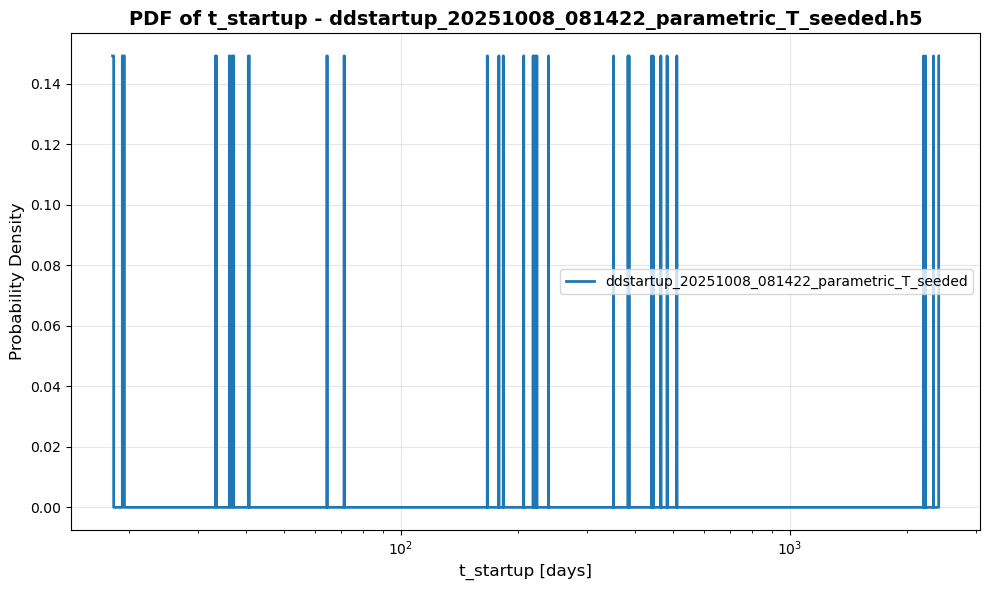

✅ Plot displayed

✅ Completed analysis for ddstartup_20251008_081422_parametric_T_seeded.h5


In [22]:
for target in target_variables:
    if target not in df.columns:
        print(f"⚠️  Target '{target}' not found in data. Skipping.")
        continue
    
    print(f"\n{'='*60}")
    print(f"🎯 Target: {target}")
    print(f"{'='*60}")
    
    # Apply filters
    df_filtered = apply_filters(df, input_filters, output_filters, target)
    
    if len(df_filtered) == 0:
        print(f"   ⚠️  No data remaining after filtering. Skipping.")
        continue
    
    # Scale target variable
    df_filtered, target_unit = scale_target(df_filtered, target)
    
    print(f"\n📊 Data after filtering:")
    print(f"   Rows: {len(df_filtered):,}")
    print(f"   Target unit: {target_unit}")
    
    # Generate PDF plot (inline)
    print(f"\n🎨 Generating PDF plot...")
    
    vmin = output_filters.get(target, {}).get('min', None)
    vmax = output_filters.get(target, {}).get('max', None)
    
    plt.figure(figsize=(10, 6))
    
    arr = df_filtered[target].values
    arr = arr[np.isfinite(arr)]
    
    if len(arr) > 0:
        counts, bins = np.histogram(arr, bins=10000, density=True)
        bin_centers = 0.5 * (bins[:-1] + bins[1:])
        mask = np.ones_like(bin_centers, dtype=bool)
        if vmin is not None:
            mask &= bin_centers >= vmin
        if vmax is not None:
            mask &= bin_centers <= vmax
        plt.plot(bin_centers[mask], counts[mask], drawstyle='steps-mid', 
                label=selected_file.stem, linewidth=2)
    
    plt.xlabel(f"{target} [{target_unit}]", fontsize=12)
    plt.ylabel('Probability Density', fontsize=12)
    plt.title(f'PDF of {target} - {selected_file.name}', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    if vmin is not None or vmax is not None:
        plt.xlim(left=vmin, right=vmax)
    
    # Use log scale if data spans multiple orders of magnitude
    if len(arr) > 0 and arr.max() / arr.min() > 100:
        plt.xscale('log')
        ax = plt.gca()
        ax.xaxis.set_major_locator(LogLocator(base=10.0, numticks=12))
        ax.xaxis.set_minor_formatter(NullFormatter())
    
    plt.tight_layout()
    plt.show()
    print(f"✅ Plot displayed")

print(f"\n✅ Completed analysis for {selected_file.name}")

## Statistical Summary

View basic statistics for each target variable per file.

In [23]:
for file_idx, selected_file in enumerate(files_to_analyze, 1):
    print(f"\n{'='*80}")
    print(f"FILE {file_idx}: {selected_file.name}")
    print(f"{'='*80}")
    
    df = load_h5_to_dataframe(selected_file)
    
    for target in target_variables:
        if target in df.columns:
            print(f"\n{target}:")
            print(df[target].describe())